# Exercise 6.2
## Interpolation
In this task, we implement a simple NN to learn a complicated function.

In [4]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

layers = keras.layers

plt.style.use("seaborn-v0_8")

### Generation of data

In [5]:
def some_complicated_function(x):
    return (
        (np.abs(x)) ** 0.5
        + 0.1 * x
        + 0.01 * x ** 2
        + 1
        - np.sin(x)
        + 0.5 * np.exp(x / 10.0)
        ) / (0.5 + np.abs(np.cos(x)))

Let's simulate the train data

In [6]:
N_train = 10**4  # number of training samples

rng = np.random.default_rng()

# Note: "[:, np.newaxis]" reshapes array to (N,1) as required by our DNN
# (we input one feature per sample)
xtrain = rng.uniform(-10, 10, N_train)[:, np.newaxis]
ytrain = some_complicated_function(xtrain) + rng.standard_normal(
    xtrain.shape
)  # train data includes some noise

In [7]:
print(f"{xtrain.shape = }")
print(f"{ytrain.shape = }")

xtrain.shape = (10000, 1)
ytrain.shape = (10000, 1)


Simulate test data

In [8]:
N_test = 10000  # number of testing samples

xtest = np.linspace(-10, 10, N_test)
ytest = some_complicated_function(xtest)

In [9]:
print(f"{xtest.shape = }")
print(f"{ytest.shape = }")

xtest.shape = (10000,)
ytest.shape = (10000,)


### Define Model

Define the number of nodes, the number of layers, and choose an activation function.
Use `keras.regularizers` to use parameter norm penalties or add a dropout layer via `layers.Dropout(fraction)`.

Here we define a model with 5 hidden layers of 100 nodes each. We choose ReLU as the activation function of every neuron (except on the output layer).

To avoid overfitting, on each layer we use a L2 weight penalty. In addition, we define a dropout of 0.2 in between of the hidden layers.

We can see the summary of the model below. It consists of 40,701 trainable parameters.

I have modified the way the input is created because I got a warning. Now, I use `layers.Input` instead of `input_shape` argument on `layers.Dense`.

In [10]:
nb_nodes = 100
nb_layers = 5
activation = "relu"

model = keras.models.Sequential(name="1Dfit")
model.add(layers.Input(shape=(xtrain.shape[1],))) # input
for i in range(nb_layers):
    model.add(
        layers.Dense(
            nb_nodes,
            activation=activation,
            kernel_regularizer=keras.regularizers.l2(0.001)
        ),
        layers.Dropout(0.2)
    )

model.add(layers.Dense(1))  # final layer

print(model.summary())

E0000 00:00:1779459963.453208   69895 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "1Dfit"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 100)            │           200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,701 (158.99 KB)

 Trainable params: 40,701 (158.99 KB)

 Non-trainable params: 0 (0.00 B)

None


### Compile the model (set an objective and choose an optimizer)

Choose an optimizer from `keras.optimizers`, e.g., `adam = keras.optimizers.Adam(learning_rate=0.001)`.

Further, choose the correct objective (loss) for this <b>regression task</b>.

We choose the mean squared error `'MSE'` as the loss function for the regression task.

In [11]:
adam = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss="MSE", optimizer=adam)

### Train the model

Train the network for a couple of epochs and save the model several times in between.

We train for 100 epochs, saving the model every 10.

In [12]:
epochs = 100
save_period = 10  # after how many epochs the model should be saved?

chkpnt_saver = keras.callbacks.ModelCheckpoint(
    "checkpoints/ex6.2-weights-{epoch:02d}.weights.h5",
    save_weights_only=True,
    save_freq=save_period
)

results = model.fit(
    xtrain,
    ytrain,
    batch_size=64,
    epochs=epochs,
    verbose=1,
    callbacks=[chkpnt_saver]
)

Epoch 1/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.0623
Epoch 2/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.5927
Epoch 3/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.2390
Epoch 4/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.9786
Epoch 5/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8168
Epoch 6/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.5980
Epoch 7/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.5863
Epoch 8/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 2.5333
Epoch 9/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2.4306
Epoch 10/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2.3899
Epoch 11/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.2623
Epoch 12/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 2.1392
Epoch 13/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.8847
Epoch 14/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1.7992
Epoch 15/100
157/157 ━━━━━━━━━━━━━━━━━━━━ 1

Compare the performance of the model during the training. You may use the skeleton below:

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 671us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 748us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 561us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 660us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 738us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step


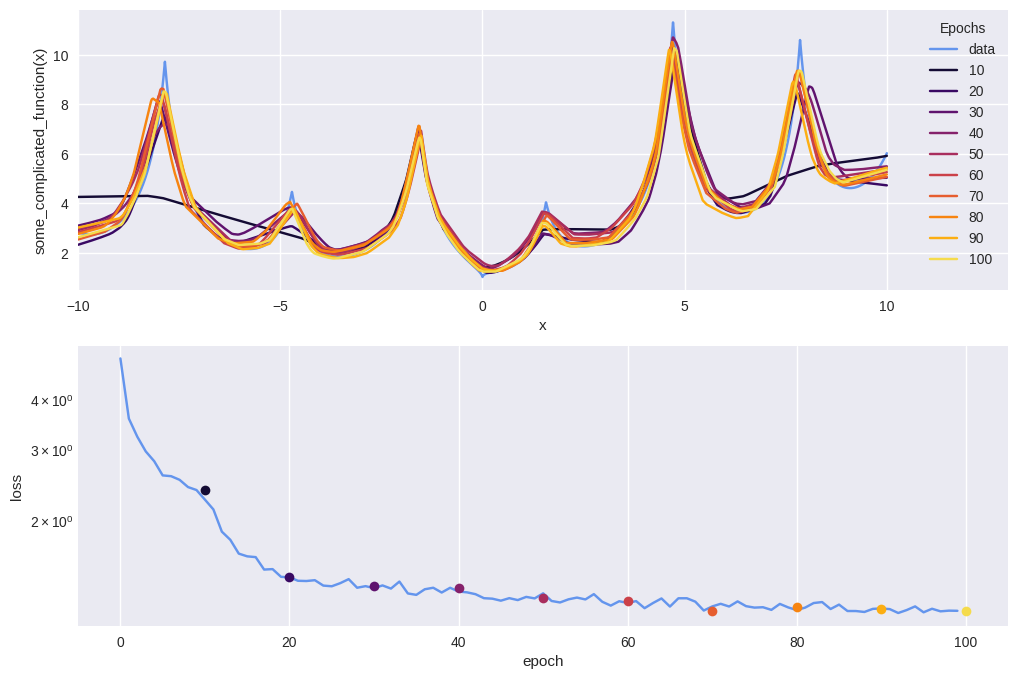

In [13]:
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(12, 8))

ax1.plot(xtest, ytest, color="#6495ED", label="data")
saved_epochs = range(save_period, epochs + 1, save_period)

colors = [
    plt.cm.inferno((i + 1) / float(len(saved_epochs) + 1))
    for i in range(len(saved_epochs))
]

for i, epoch in enumerate(saved_epochs):
    model.load_weights("checkpoints/ex6.2-weights-{epoch:02d}.weights.h5".format(epoch=epoch))
    ypredict = model.predict(xtest).squeeze()
    ax1.plot(xtest.squeeze(), ypredict, color=colors[i], label=epoch)
    ax2.plot(
        epoch,
        results.history["loss"][epoch - 1],
        color=colors[i],
        marker="o",
        zorder=10,
    )

ax1.set(xlabel="x", ylabel="some_complicated_function(x)", xlim=(-10, 13), title="")
ax1.grid(True)
ax1.legend(loc="upper right", title="Epochs")

ax2.plot(results.history["loss"], color="#6495ED")
ax2.set(xlabel="epoch", ylabel="loss")
ax2.grid(True)
ax2.semilogy()

plt.show()

The performance improves over epochs, however, after 50 epochs it stays almost constant, which indicates the training should be stopped then to avoid overfitting. Still, the reconstruction of the complicated function is good. We can see only the last prediction below.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 524us/step


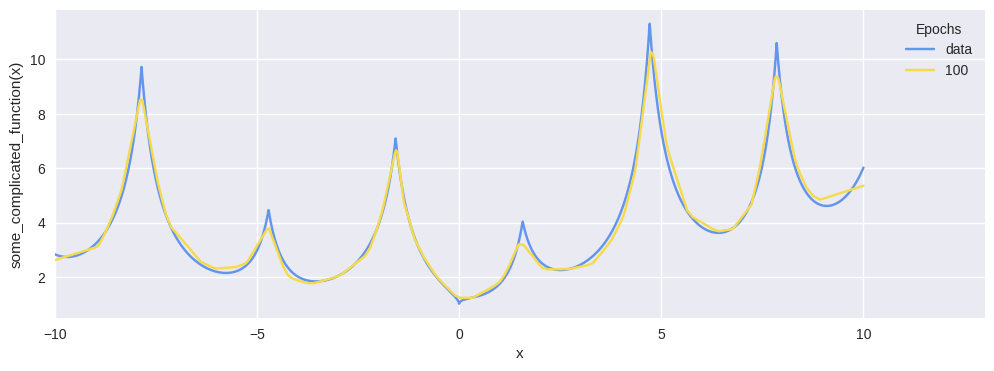

In [14]:
fig, ax1 = plt.subplots(nrows=1, figsize=(12, 4))

ax1.plot(xtest, ytest, color="#6495ED", label="data")
model.load_weights("checkpoints/ex6.2-weights-100.weights.h5".format(epoch=epoch))
ypredict = model.predict(xtest).squeeze()
ax1.plot(xtest.squeeze(), ypredict, color=colors[-1], label='100')

ax1.set(xlabel="x", ylabel="some_complicated_function(x)", xlim=(-10, 13), title="")
ax1.grid(True)
ax1.legend(loc="upper right", title="Epochs")

plt.show()